**Resume / Candidate Screening System**

In [11]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
df = pd.read_csv(r"C:\Users\sanka\Desktop\FUTURE_ML_03\Resume.csv")

In [23]:
df.head()

,ID,Resume_str,Resume_html,Category,clean_resume,skills,skill_score,tfidf_score,final_score,missing_skills
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering quality technician career overview...,"[python, machine learning, sql, data analysis,...",80.0,8.70,30.09,[nlp]
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,"[python, machine learning, sql, data analysis,...",80.0,7.59,29.31,[nlp]
1348,22946204,Highlights Prog. Languages: ...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,highlights prog languages c 5 yrs python 3 yrs...,"[python, machine learning, sql, data analysis]",80.0,5.30,27.71,[nlp]
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,"[python, machine learning, sql, c++]",60.0,5.47,21.83,"[data analysis, nlp]"
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial s...,"[python, sql, data analysis]",60.0,5.23,21.66,"[nlp, machine learning]"


In [14]:
job_description = """
Looking for a Data Scientist with skills in Python, Machine Learning,
NLP, SQL, and Data Analysis.
"""


In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.replace("C++", "cplusplus").replace("c++", "cplusplus")
    text = text.replace("C#", "csharp").replace("c#", "csharp")
    text = text.replace(".NET", "dotnet").replace(".net", "dotnet")
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_resume'] = df['Resume_str'].fillna("").apply(clean_text)

In [16]:
skills_list = [
    "python",
    "machine learning",
    "nlp",
    "sql",
    "data analysis",
    "tensorflow",
    "c++",
    "c#",
    ".net",
]

skill_aliases = {
    "machine learning": ["machine learning", "ml"],
    "data analysis": ["data analysis", "data analytics"],
    "c++": ["c++", "cplusplus"],
    "c#": ["c#", "csharp"],
    ".net": [".net", "dotnet"],
}

def build_skill_patterns(skills, aliases):
    patterns = {}
    for skill in skills:
        terms = aliases.get(skill, [skill])
        term_patterns = []
        for term in terms:
            term = term.lower()
            term = term.replace("c++", "cplusplus").replace("c#", "csharp").replace(".net", "dotnet")
            term = re.escape(term).replace(r"\ ", r"\s+")
            term_patterns.append(r"\b" + term + r"\b")
        patterns[skill] = re.compile("|".join(term_patterns))
    return patterns

skill_patterns = build_skill_patterns(skills_list, skill_aliases)

In [17]:
def extract_skills(text):
    skills_found = []
    for skill, pattern in skill_patterns.items():
        if pattern.search(text):
            skills_found.append(skill)
    return skills_found

df['skills'] = df['clean_resume'].apply(extract_skills)

In [18]:
jd_clean = clean_text(job_description)
jd_skills = extract_skills(jd_clean)
jd_skills


['python', 'machine learning', 'nlp', 'sql', 'data analysis']

In [19]:
def calculate_skill_score(resume_skills):
    matched = set(resume_skills) & set(jd_skills)
    if not jd_skills:
        return 0.0
    score = (len(matched) / len(jd_skills)) * 100
    return round(score, 2)

df['skill_score'] = df['skills'].apply(calculate_skill_score)

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(df['clean_resume'].tolist() + [jd_clean])
jd_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]
similarities = cosine_similarity(resume_vectors, jd_vector).flatten()
df['tfidf_score'] = (similarities * 100).round(2)

df['final_score'] = (0.7 * df['tfidf_score'] + 0.3 * df['skill_score']).round(2)

In [20]:
def find_missing(resume_skills):
    return list(set(jd_skills) - set(resume_skills))

df['missing_skills'] = df['skills'].apply(find_missing)


In [24]:
df = df.sort_values(by='final_score', ascending=False)
df[["ID", "Category", "final_score", "skill_score", "tfidf_score", "skills", "missing_skills"]].head()


,ID,Category,final_score,skill_score,tfidf_score,skills,missing_skills
1762,12011623,ENGINEERING,30.09,80.0,8.70,"[python, machine learning, sql, data analysis,...",[nlp]
1218,21156767,CONSULTANT,29.31,80.0,7.59,"[python, machine learning, sql, data analysis,...",[nlp]
1348,22946204,AUTOMOBILE,27.71,80.0,5.30,"[python, machine learning, sql, data analysis]",[nlp]
2153,34953092,BANKING,21.83,60.0,5.47,"[python, machine learning, sql, c++]","[data analysis, nlp]"
1339,18448085,AUTOMOBILE,21.66,60.0,5.23,"[python, sql, data analysis]","[nlp, machine learning]"


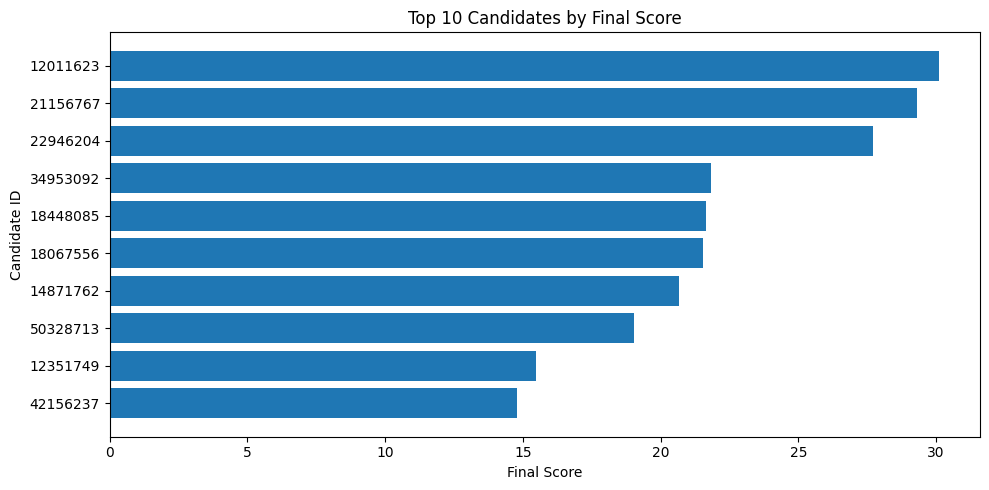

In [25]:
top_n = 10
top_candidates = df.head(top_n)

plt.figure(figsize=(10, 5))
plt.barh(top_candidates['ID'].astype(str), top_candidates['final_score'])
plt.gca().invert_yaxis()
plt.xlabel('Final Score')
plt.ylabel('Candidate ID')
plt.title(f'Top {top_n} Candidates by Final Score')
plt.tight_layout()
plt.show()